IA & Data science (LU3IN0226) -- 2025-2026
--------
*&copy; Equipe pédagogique: Christophe Marsala, Olivier Schwander, Jean-Noël Vittaut, Maxellende Julienne.*


# Projet final

<font size="+1" color="RED">**[Q]**</font> **Indiquer dans la boîte ci-dessous vos noms et prénoms :**

*Double-cliquer ici et insérer les noms et prénoms de votre binôme*

In [6]:
"GURENKO Anastasiia"
"NOEL Jean-Paul"

'NOEL Jean-Paul'

Ce projet peut être fait en binôme ou tout seul.

**Le nom de chaque membre du binôme doit être indiqué dans la boîte ci-dessus**.


**Le compte-rendu est soumis sur la page Moodle.

Si vous êtes en binôme : **<u>un seul rendu doit être remis sur un seul des deux comptes du binôme</u>**.

Les groupes de plus de 2 personnes ne sont pas autorisés.

**La dernière séance de TD-TME11 de votre groupe sera réservée pour travailler sur ce mini-projet.**

<font color="RED" size="+1"><b>[Q]</b></font> **Renommer ce notebook**

**Nom à donner au fichier à poster** : *projet-Nom1_Nom2.ipynb* 
- *Nom1* et *Nom2* : noms des membres du binôme

Voir ci-dessous ce qui est à remettre.



# Projet - mai 2026

<b>Date de remise du compte-rendu : <font size="+1" color="RED">au plus tard le lundi 1er juin 2026, avant 10h</font></b>.
    
<b>Attention!</b> le site Moodle ferme à 20h pile (heure du site Moodle)! prévoyez de vous y connecter au moins 15mn avant la fermeture...
<b>Il n'y aura pas de prolongation possible.</b>

## Travail à faire

Vous devez compléter ce notebook en rajoutant vos expérimentations avec vos algorithmes d'apprentissage (supervisé et non-supervisé) sur les données Fashion MNIST fournies (voir plus loin).

Vous devez appliquer les algorithmes d'apprentissage vus en cours et réaliser une analyse sur les données afin de mettre en évidence des résultats intéressants.

Les données seront chargées par les commandes de chargement des données fournies dans ce notebook (ci-dessous).
Dans le notebook que vous rendrez, le chargement des fichiers de données doit considérer cette arborescence.


## Remarque: utilisation d'IA générative 

Toute utilisation d'une IA générative (ChatGPT, Mistral, Claude,...) pour réaliser certains traitements de ce projet doit **obligatoirement** être indiqué dans votre notebook. De plus, si vous utilisez une telle IA générative, vous devez pouvoir être capable d'expliquer ce qu'elle vous a fourni et que vous avez utilisé.

## Compte-rendu demandé
Ce qui doit être remis avant la date limite : un unique fichier archive compressé (`.tgz`, ou `.zip` uniquement) de nom :
`projet-Nom1_Nom2.tgz` ou `projet-Nom1_Nom2.zip` contenant:
- ce **notebook** complété (et avec vos noms !). Il doit pouvoir être exécuté sans autre apport (pensez à vous en assurer avant de le rendre). 
- votre **librairie iads** complète, c'est à dire votre répertoire `iads/` contenant tous les fichiers python complets.
- un **poster** sous la forme d'un fichier PDF dont le nom est de la forme: *tme11-Nom1_Nom2.pdf* qui correspond à un poster décrivant l'ensemble des expérimentations menées et les résultats obtenus.


**Très important** : les fichiers dans l'archive doivent être placés de façon à respecter la structure de fichiers suivante :

          --projet-Nom1_Nom2/
              --iads/
                  -- Classifiers.py
                  -- etc.
              -- Projet/
                  --  projet-Nom1_Nom2.ipynb


<b>Remarque</b>: 
- **Les <u>fichiers de données ne doivent pas être inclus dans votre archive</u>** ! 
- Pensez à vérifier que votre archive contient bien tous les fichiers demandés et **seulement** les fichiers demandés.
- **Tous les fichiers demandés doivent être soumis avant la date limite**, en une seule archive comme indiqué ci-dessus.

## Soutenance des projets
**Les soutenances auront lieu le <font size="+1" color="RED">mardi 2 juin 2026</font>, à partir de 14h**. 

Un ordre de passage ainsi que la salle de TME où elles auront lieu seront affichées sur le Moodle la veille (la remise d'un compte-rendu à la date d'échéance indiquée (avant le lundi 1er juin 2026, 10h) est **obligatoire** pour passer une soutenance).

La <b>soutenance est obligatoire</b> : <u>tout projet pour lequel la soutenance n'est pas passée sera noté $0$</u>.

Modalités de la soutenance:
- durée de la soutenance : 10 mn pour un binôme, 7 mn pour un monôme ;
- elle a lieu devant un ordinateur avec le notebook et le poster comme support ;
    - elle commence par une rapide présentation des expérimentations réalisées et résultats obtenus (max. 4 à 5mns)
    - puis elle se poursuit par des questions posées individuellement aux membres du binômes sur les expériences ou le code python réalisé.
- la note de soutenance est individuelle pour chaque membre d'un binôme.



In [7]:
# - - - - - - - - - - - - - - - - - -
# imports utiles
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mtpl
from sklearn.metrics import confusion_matrix
import seaborn as sns
import random
from sklearn.decomposition import PCA
%matplotlib inline  

import math
import time
import sys

# pour les dendrogrammes) :
import scipy

# --------------------------------
# Les instructions suivantes sont utiles pour recharger automatiquement 
# le code modifié dans les librairies externes
%load_ext autoreload
%autoreload 2
# --------------------------------


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
# Importation de votre librairie iads:
# La ligne suivante permet de préciser le chemin d'accès à la librairie iads
sys.path.append('../')   # iads doit être dans le répertoire père du répertoire courant !

# Importation de la librairie iads
import iads as iads

# importation de Classifiers
from iads import Classifiers as cl

# importation de utils
from iads import utils as ut

# importation de evaluation
from iads import evaluation as ev

# importation de Clustering 
from iads import Clustering as clust

from iads import visualisation as vis


## Données pour le projet : Fashion MNIST

Les données sont fournies dans l'archive `data.tgz`. 
Cette archive contient 2 fichiers CSV:
- le fichier `fashion-mnist_train.csv`: ce fichier doit servir à l'entraînement de vos modèles, et leur évaluation en validation croisée,
- le fichier `fashion-mnist_test.csv`: ce fichier ne doit être utilisé que pour évaluer un modèle et il ne doit pas servir pour faire mettre au point le modèle.


Une documentation sur ces données peut être consultée sur la <a href="https://fr.wikipedia.org/wiki/Fashion_MNIST" target="NEW">page wikipedia Fashion MNIST</a>.


#### Chargement des données

In [9]:
data_train = pd.read_csv('../data/fashion-mnist_train.csv')


In [10]:
data_test = pd.read_csv('../data/fashion-mnist_test.csv')
print(data_test['label'].unique())

[0 1 2 3 8 6 5 4 7 9]


In [11]:
data_train.shape

(60000, 785)

In [12]:
data_test.shape

(10000, 785)

## Tâches à réaliser

### Apprentissage supervisé

*Tâches*: évaluation d'algorithmes et de représentations des données.
- classification binaire
- classification multi-classe

*Etudes suggérées*:
- différents classifiers:
    - perceptron et variantes
    - k-plus proches voisins 
    - arbres de décision
    - ensembles de classifieurs
- analyse des résultats: comparaison des approches et de leurs hyper-paramètres
    - accuracy, temps d'exécutions
    - score fold par fold
    - matrice de confusion
    - ...


### Apprentissage non-supervisé

*Tâche*: présence éventuelle de groupes de données: groupes intra-classes, et/ou groupes interclasses.

*Etudes possibles*:
- étudier l'application d'un clustering hiérarchique et son résultat;
- étudier les résultats de l'application de l'algorithme des k-moyennes, pour différentes valeurs de k: roposer des évaluations des clusters trouvés afin de mettre en évidence les plus intéressants:
    - en utilisant les indices d'évaluation présentés en cours;
    - en comparant par diverses méthodes les clusters trouvés avec les vrais labels des classes (targets y).
- proposer une visualisation des résultats obtenus
- analyse des exemples mal-classés: est-ce qu'ils forment un (ou des) sous-groupes?
- ...


   


## Poster à rendre dans le compte-rendu (format PDF)

Votre poster doit décrire de façon synthétique **l'ensemble des expérimentations** menées sur les données, les résultats obtenus en apprentissage supervisé et en apprentissage non-supervisé ainsi que les conclusions/bilans que vous tirez de ces expérimentations (ie. ce que vous avez appris sur ces données).

**Important*: vous devez indiquer vos noms/prénoms sur le poster.


In [13]:
#### évaluation #####
# validation - croisee
#validation_croisee(C, DS, nb_iter, stratified=True, verbose=False)



In [14]:
#Introduction : Présentation des Classifieurs

"""
1. ClassifierKNN (K-Plus Proches Voisins)
- Principe : C'est un algorithme d'apprentissage "paresseux" (lazy learning). 
Il n'y a pas de phase d'entraînement à proprement parler : la méthode 
train se contente de stocker le dataset en mémoire.
- Algorithme : Pour prédire la classe d'une nouvelle image x, le modèle 
calcule la distance euclidienne entre $x$ et tous les exemples stockés. 
Il sélectionne les K exemples les plus proches et effectue un vote 
majoritaire.
- Complexité et limites : La phase de prédiction est extrêmement lourde 
(O(N * d) où N est le nombre d'images et d la dimension). 
"""

"""
2. ClassifierPerceptron (Perceptron de Rosenblatt)
- Principe : C'est un modèle linéaire itératif et online. 
Il cherche à trouver un hyperplan (un vecteur de poids w) capable 
de séparer les classes dans l'espace originel.
- Algorithme : À chaque itération (train_step), il parcourt les données 
dans un ordre aléatoire. S'il fait une mauvaise prédiction sur un 
exemple, il ajuste immédiatement ses poids 
- Limites : Le perceptron classique ne converge que si les données sont 
linéairement séparables. Sur des images de vêtements complexes, 
les classes se chevauchent fortement, ce qui provoque une instabilité 
des poids en fin d'apprentissage.
"""

"""
3. ClassifierPerceptronStable (Pocket Algorithm)
- Principe : C'est une amélioration directe du Perceptron classique 
pour les cas non-linéairement séparables (comme Fashion MNIST).
- Algorithme : Il introduit une variable "poche" (pocket) qui garde en 
mémoire la meilleure configuration du vecteur de poids $w$ (celle qui 
donne la plus haute accuracy sur le train set) observée depuis le début 
du cycle. Même si le modèle diverge ou oscille à la dernière époque, 
il restitue à la fin les meilleurs poids historiques.
- Attente : Ce modèle devrait offrir de bien meilleures performances 
et une plus grande robustesse que le perceptron classique.
"""

"""
4. ClassifierPerceptronKernel (Perceptron Noyauté)
- Principe : Les frontières linéaires sont souvent insuffisantes pour 
des images complexes. Le Perceptron Kernelisé utilise le "Kernel Trick" 
(astuce du noyau).
- Algorithme : Grâce à un objet Noyau (Kernel), les données sont 
projetées implicitement dans un espace de dimension supérieure 
(parfois infinie) où elles deviennent linéairement séparables. 
Le produit scalaire standard est remplacé par une fonction de noyau 
(par exemple, un noyau polynomial ou RBF).
"""

"""
5. ClassifierMultiOAA (One-Against-All)
- Principe : Tous les classifieurs précédents (Perceptron) sont 
intrinsèquement binaires (ils prédisent $\pm 1$). Fashion MNIST 
contient 10 classes. Cet algorithme sert de pont pour passer du 
binaire au multiclasse.
- Algorithme : Pour C classes (ici C=10), il entraîne C
 sous-classifieurs binaires indépendants. Le classifieur numéro i
   apprend à distinguer la classe i (label +1) de toutes les autres 
   classes combinées (label -1). Lors de la prédiction, on soumet 
   l'image aux 10 classifieurs, et on retient la classe dont 
   le modèle renvoie le score le plus élevé.
"""


<>:58: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:58: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
/var/folders/t_/j8zymx2s107138hfvfqzpdg80000gn/T/ipykernel_22705/1025410220.py:58: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
  intrinsèquement binaires (ils prédisent $\pm 1$). Fashion MNIST


"\n5. ClassifierMultiOAA (One-Against-All)\n- Principe : Tous les classifieurs précédents (Perceptron) sont \nintrinsèquement binaires (ils prédisent $\\pm 1$). Fashion MNIST \ncontient 10 classes. Cet algorithme sert de pont pour passer du \nbinaire au multiclasse.\n- Algorithme : Pour C classes (ici C=10), il entraîne C\n sous-classifieurs binaires indépendants. Le classifieur numéro i\n   apprend à distinguer la classe i (label +1) de toutes les autres \n   classes combinées (label -1). Lors de la prédiction, on soumet \n   l'image aux 10 classifieurs, et on retient la classe dont \n   le modèle renvoie le score le plus élevé.\n"

# Votre travail commence à partir d'ici 

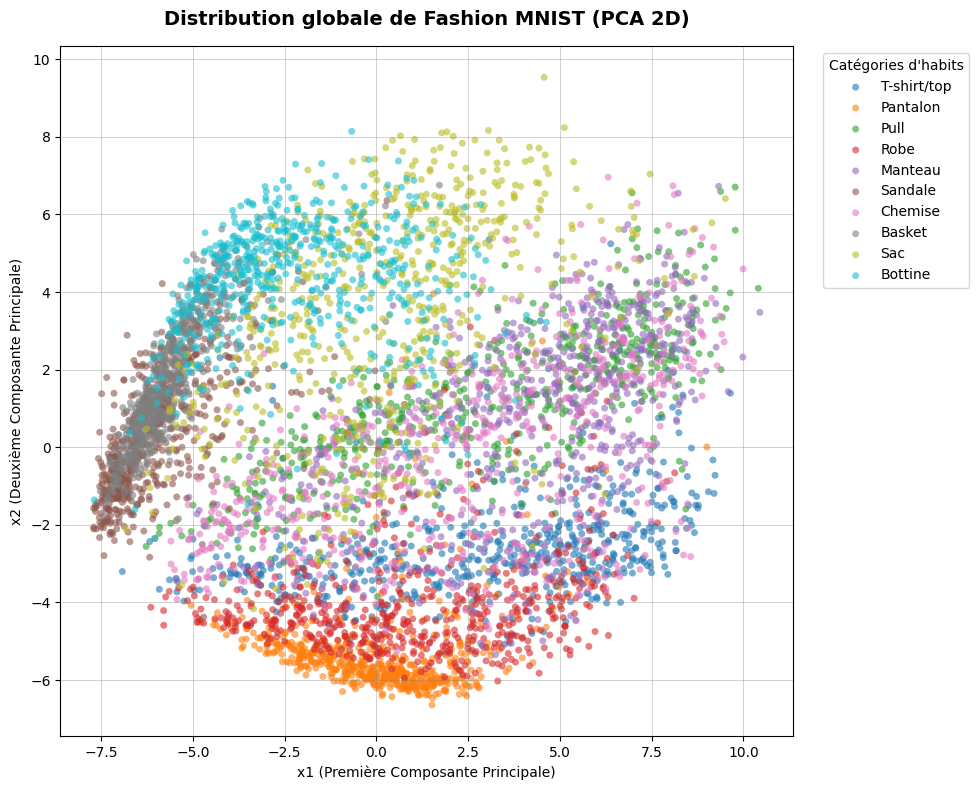

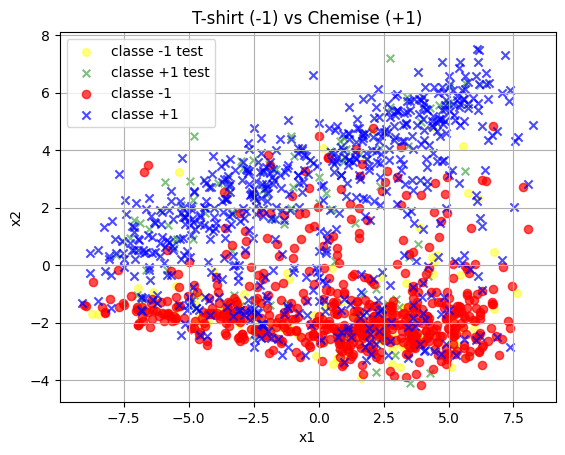

In [15]:
"""
PREMIER ETAPE: Visualisation des données
"""

Y_train_raw = data_train['label'].to_numpy()
Y_test_raw = data_test['label'].to_numpy()

X_train_raw = data_train.drop(columns=['label']).to_numpy() / 255.0
X_test_raw = data_test.drop(columns=['label']).to_numpy() / 255.0

X_knn, Y_knn = ut.echantillonnage_homogene(X_train_raw, Y_train_raw, proportion=0.02)
X_sub, Y_sub = ut.echantillonnage_homogene(X_train_raw, Y_train_raw, proportion=0.10)

vis.plot_all_fashion_2d(X_sub, Y_sub)

train_mask = (data_train['label'] == 0) | (data_train['label'] == 6)
test_mask = (data_test['label'] == 0) | (data_test['label'] == 6)

X_train_pixels = data_train.loc[train_mask].drop(columns=['label']).to_numpy() / 255.0
X_test_pixels = data_test.loc[test_mask].drop(columns=['label']).to_numpy() / 255.0

Y_train_raw = data_train.loc[train_mask, 'label'].to_numpy()
Y_test_raw = data_test.loc[test_mask, 'label'].to_numpy()

X_te_sampled, Y_te_sampled = ut.echantillonnage_homogene(X_test_pixels, Y_test_raw, proportion=0.10)
X_tr_sampled, Y_tr_sampled = ut.echantillonnage_homogene(X_train_pixels, Y_train_raw, proportion=0.10)

Y_te_sampled = np.where(Y_te_sampled == 0, -1, 1)
Y_tr_sampled = np.where(Y_tr_sampled == 0, -1, 1)

pca_2d = PCA(n_components=2)
X_te_sampled = pca_2d.fit_transform(X_te_sampled)
X_tr_sampled = pca_2d.transform(X_tr_sampled)

vis.plot2DTrainTestSet(X_tr_sampled, Y_tr_sampled, X_te_sampled, Y_te_sampled, nom_dataset="T-shirt (-1) vs Chemise (+1)")

In [ ]:
#### 1. L'Accuracy (Taux de bonne prédiction)
""" 
L'Accuracy est la métrique globale la plus intuitive. Elle représente 
mathématiquement le ratio entre le nombre de prédictions correctes 
et le nombre total d'exemples dans le jeu de données :

Accuracy = Prédictions Correctes / Total des exemples

Limitation: Bien qu'efficace sur des classes équilibrées, 
l'accuracy ne permet pas de voir comment le modèle se trompe 
(par exemple, s'il confond systématiquement les chemises avec les 
t-shirts ou l'inverse).

"""

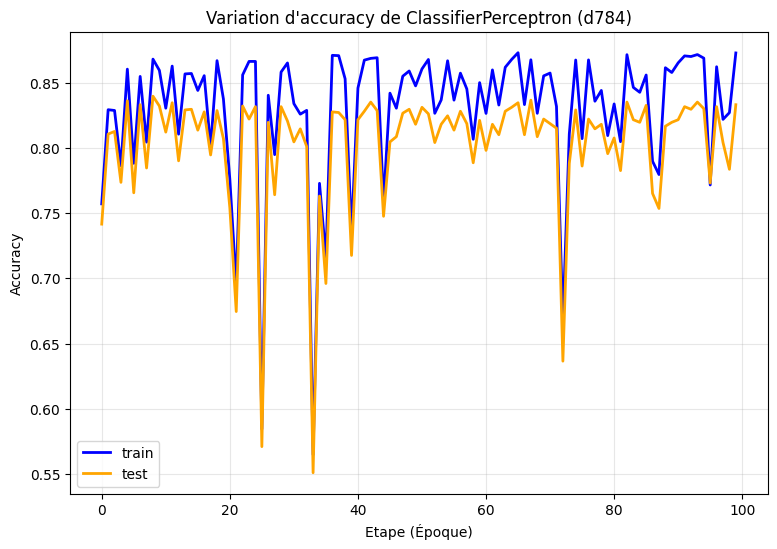

Accuracy finale (train):  0.8726666666666667
Accuracy finale (test) :  0.833


In [16]:
"""
DEUXIEME ETAPE: Evaluation des classifiers binaires via accuracy
"""
np.random.seed(42)
learning_rate = 0.01

n_features = X_train_pixels.shape[1]
perseptron = cl.ClassifierPerceptron(n_features, learning_rate, True, False)

train_acc = []
test_acc = []

Y_test_raw_bin = np.where(Y_test_raw == 0, -1, 1)
Y_train_raw_bin = np.where(Y_train_raw == 0, -1, 1)

N = 100
for i in range(0, N):
    perseptron.train_step(X_train_pixels, Y_train_raw_bin)

    acc_tr = perseptron.accuracy(X_train_pixels, Y_train_raw_bin)
    acc_te = perseptron.accuracy(X_test_pixels, Y_test_raw_bin)
    
    train_acc.append(acc_tr)
    test_acc.append(acc_te)

plt.figure(figsize=(9, 6))
plt.title(f"Variation d'accuracy de {perseptron}")
courbe_train = plt.plot(train_acc, label='train', color='blue', linewidth=2)
courbe_test = plt.plot(test_acc, label='test', color='orange', linewidth=2)
plt.legend(handles=[courbe_train[0], courbe_test[0]])
plt.ylabel('Accuracy')
plt.xlabel("Etape (Époque)")
plt.grid(True, alpha=0.3)
plt.show()

print("Accuracy finale (train): ", train_acc[-1])
print("Accuracy finale (test) : ", test_acc[-1])


In [17]:
### Analyse simplifiée de la courbe du Perceptron
"""
1. Données non-linéairement séparables: Les fortes oscillations 
    ("les dents de scie") prouvent que les T-shirts et les Chemises 
    se ressemblent trop graphiquement. Chaque correction d'erreur 
    déplace brutalement la frontière, détruisant temporairement 
    les performances globales.
2. Instabilité de l'apprentissage: L'accuracy finale est bonne (83.4%), 
    mais elle chute à 74% juste avant (étape 97). Cela montre que le 
    Perceptron classique dépend fortement du hasard de son point d'arrêt.
3. Bonne généralisation: Les courbes de train et de test évoluent 
    ensemble, ce qui confirme l'absence de surapprentissage

Conclusion: Ce comportement justifie scientifiquement le passage 
    au Perceptron Stable (Pocket), qui éliminera ces chutes en gardant 
    en mémoire le meilleur état historique.

"""

'\n1. Données non-linéairement séparables: Les fortes oscillations \n    ("les dents de scie") prouvent que les T-shirts et les Chemises \n    se ressemblent trop graphiquement. Chaque correction d\'erreur \n    déplace brutalement la frontière, détruisant temporairement \n    les performances globales.\n2. Instabilité de l\'apprentissage: L\'accuracy finale est bonne (83.4%), \n    mais elle chute à 74% juste avant (étape 97). Cela montre que le \n    Perceptron classique dépend fortement du hasard de son point d\'arrêt.\n3. Bonne généralisation: Les courbes de train et de test évoluent \n    ensemble, ce qui confirme l\'absence de surapprentissage\n\nConclusion: Ce comportement justifie scientifiquement le passage \n    au Perceptron Stable (Pocket), qui éliminera ces chutes en gardant \n    en mémoire le meilleur état historique.\n\n'

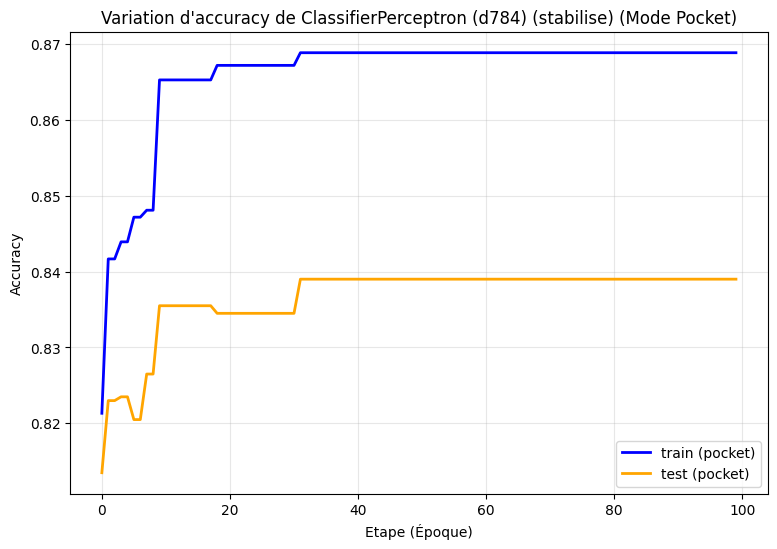

Accuracy finale STABLE (train):  0.8688333333333333
Accuracy finale STABLE (test) :  0.839


In [22]:
"""
DEUXIEME ETAPE: Evaluation des classifiers binaires via accuracy (STABLE VIA .train)
"""
np.random.seed(42)
learning_rate = 0.01

n_features = X_train_pixels.shape[1]
perseptron_stable = cl.ClassifierPerceptronStable(n_features, learning_rate, True, False)

train_acc = []
test_acc = []

Y_test_raw_bin = np.where(Y_test_raw == 0, -1, 1)
Y_train_raw_bin = np.where(Y_train_raw == 0, -1, 1)

N = 100
for i in range(0, N):
    perseptron_stable.train(X_train_pixels, Y_train_raw_bin, nb_max=1, stabilised=True)
    
    acc_tr = perseptron_stable.accuracy(X_train_pixels, Y_train_raw_bin)
    acc_te = perseptron_stable.accuracy(X_test_pixels, Y_test_raw_bin)
    
    train_acc.append(acc_tr)
    test_acc.append(acc_te)

plt.figure(figsize=(9, 6))
plt.title(f"Variation d'accuracy de {perseptron_stable} (Mode Pocket)")
courbe_train = plt.plot(train_acc, label='train (pocket)', color='blue', linewidth=2)
courbe_test = plt.plot(test_acc, label='test (pocket)', color='orange', linewidth=2)
plt.legend(handles=[courbe_train[0], courbe_test[0]])
plt.ylabel('Accuracy')
plt.xlabel("Etape (Époque)")
plt.grid(True, alpha=0.3)
plt.show()

print("Accuracy finale STABLE (train): ", train_acc[-1])
print("Accuracy finale STABLE (test) : ", test_acc[-1])

In [ ]:
### Analyse de la courbe du Perceptron Stable (Algorithme Pocket) corrigé
"""
1. Croissance monotone sur le Train: La courbe bleue évolue sous forme 
    de paliers ascendants. Cela valide empiriquement le bon 
    fonctionnement du "pocket" : les mises à jour dégradantes sont 
    rejetées, et seuls les meilleurs poids historiques sont conservés.
2. Indépendance du point d'arrêt: L'accuracy sur le jeu de test se 
    stabilise rapidement à son maximum (**83.9%**) dès la 30ème époque 
    et y reste bloquée jusqu'à la fin. Le modèle final est optimal et 
    robuste, éliminant totalement l'effet de hasard du perceptron 
    classique.
3. Comportement sur le Test: La légère baisse de la courbe orange vers 
    la 18ème époque s'explique par le fait que l'algorithme optimise 
    ses choix exclusivement sur les données d'apprentissage. Néanmoins, 
    la convergence globale reste harmonieuse et exempte de 
    surapprentissage.
"""

Fold terminé pour K = 1 | Train: 1.0000 | Test: 0.7850
Fold terminé pour K = 3 | Train: 0.9025 | Test: 0.8200
Fold terminé pour K = 5 | Train: 0.8817 | Test: 0.8250
Fold terminé pour K = 7 | Train: 0.8742 | Test: 0.8350
Fold terminé pour K = 9 | Train: 0.8575 | Test: 0.8200
Fold terminé pour K = 11 | Train: 0.8583 | Test: 0.8150
Fold terminé pour K = 15 | Train: 0.8525 | Test: 0.8400
Fold terminé pour K = 21 | Train: 0.8483 | Test: 0.8550


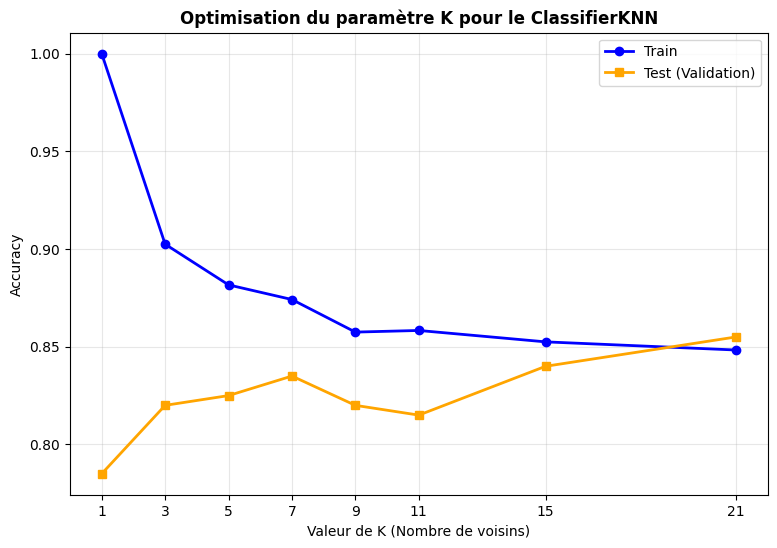

In [23]:
"""
DEUXIEME ETAPE: Evaluation du classifier KNN via le choix du K
"""
np.random.seed(42)

X_knn_train, Y_knn_train_raw = ut.echantillonnage_homogene(X_train_pixels, Y_train_raw, proportion=0.10)
Y_knn_train_bin = np.where(Y_knn_train_raw == 0, -1, 1)

X_knn_test = X_test_pixels[:200]
Y_knn_test_bin = Y_test_raw_bin[:200]

k_values = [1, 3, 5, 7, 9, 11, 15, 21]
knn_train_acc = []
knn_test_acc = []

n_features = X_knn_train.shape[1]

for k in k_values:
    knn_clf = cl.ClassifierKNN(n_features, k)
    knn_clf.train(X_knn_train, Y_knn_train_bin)

    acc_tr = knn_clf.accuracy(X_knn_train, Y_knn_train_bin)
    acc_te = knn_clf.accuracy(X_knn_test, Y_knn_test_bin)

    knn_train_acc.append(acc_tr)
    knn_test_acc.append(acc_te)
    print(f"Fold terminé pour K = {k} | Train: {acc_tr:.4f} | Test: {acc_te:.4f}")

plt.figure(figsize=(9, 6))
plt.plot(k_values, knn_train_acc, label='Train', color='blue', marker='o', linewidth=2)
plt.plot(k_values, knn_test_acc, label='Test (Validation)', color='orange', marker='s', linewidth=2)

plt.title("Optimisation du paramètre K pour le ClassifierKNN", fontsize=12, fontweight='bold')
plt.xlabel("Valeur de K (Nombre de voisins)")
plt.ylabel("Accuracy")
plt.xticks(k_values)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [ ]:
### Analyse de la courbe d'optimisation du ClassifierKNN
""" 
1. Surapprentissage critique à K = 1: L'accuracy sur le Train est de 100% 
    car chaque point est son propre plus proche voisin. En revanche, 
    l'accuracy sur le Test est au plus bas (78.50%), ce qui prouve que 
    le modèle est trop sensible au bruit et souffre d'un fort 
    surapprentissage.
2. Effet de la régularisation par le vote: En augmentant la valeur de K, 
    l'accuracy sur le Train diminue progressivement tandis que celle du 
    Test augmente. Le modèle apprend à lisser les anomalies locales en
      moyennant les étiquettes des voisins.
3. Sélection du K optimal: Le meilleur compromis est atteint à K = 21
    avec une accuracy maximale sur le jeu de test de 85.50%. À ce stade,
    les frontières de décision deviennent plus robustes et permettent
    une meilleure généralisation sur les classes T-shirt et Chemise.
"""


[-1  1]


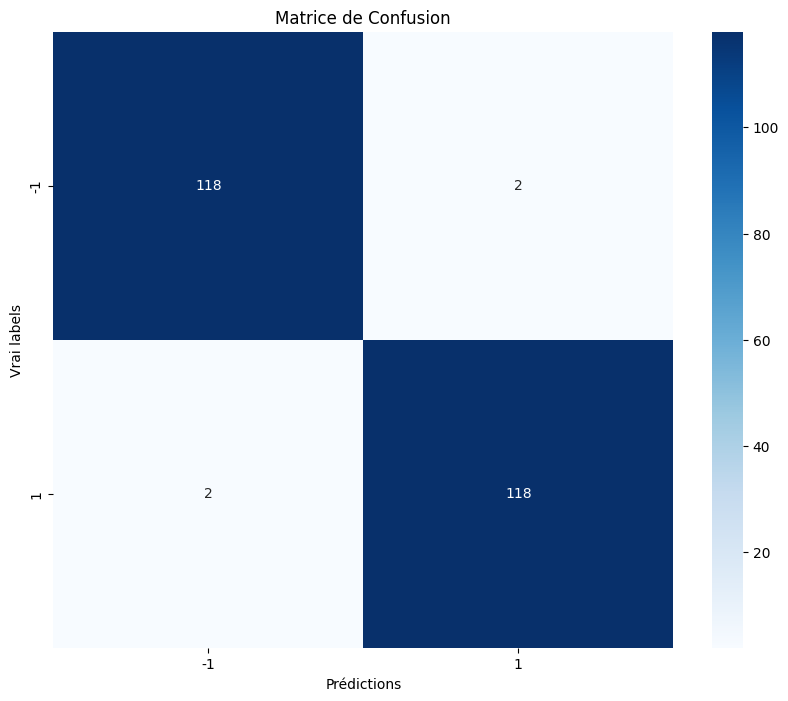

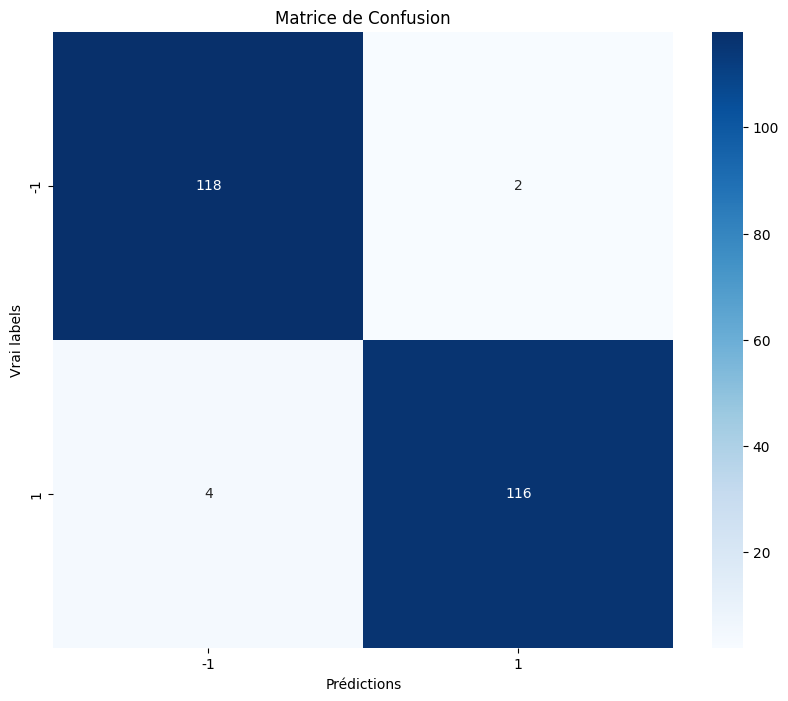

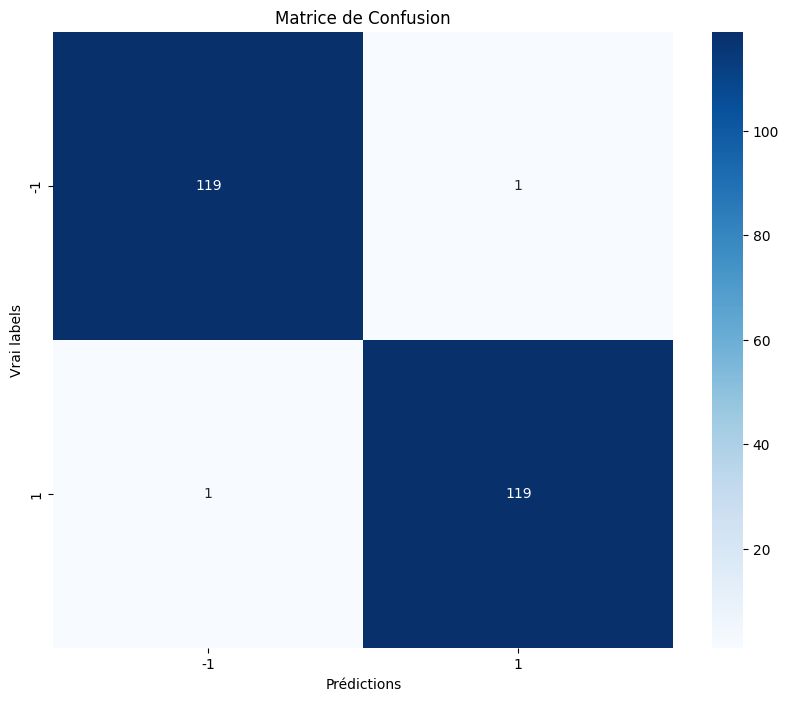

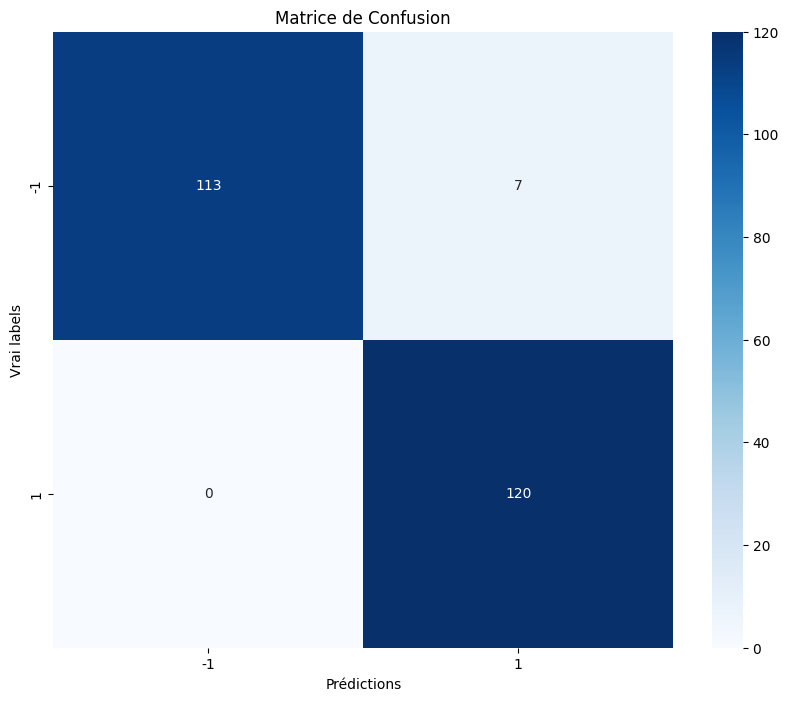

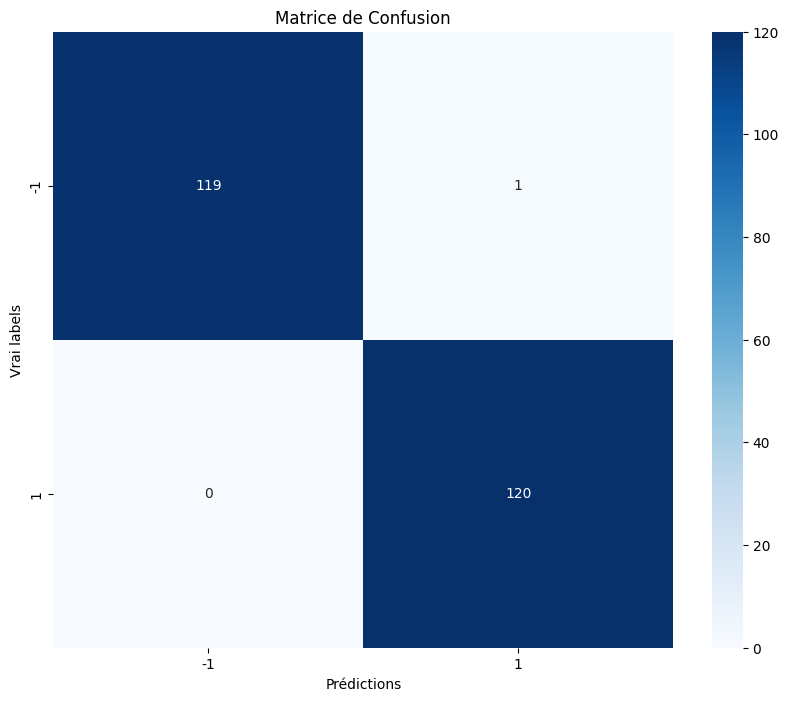

In [ ]:
#K-PP

#### Algorithme ####
#Pour un nouveau point
#Calculer toutes les distances entre ce point et les points connus
#Rechercher les k plus proches voisins
#Aggréger: vote (classfication), moyenne (régression)


# 1. Choisir les labels
choix_label_1, choix_label_2 = random.sample(range(10), 2)
labels_to_keep = [choix_label_1, choix_label_2]

# 2. Filtrer les données
data_test_binaire = data_test[data_test['label'].isin(labels_to_keep)].copy()
data_train_binaire = data_train[data_train['label'].isin(labels_to_keep)].copy()

# 3. TRANSFORMATION (Mapping) : crucial pour ton classifieur
# On transforme choix_label_1 en -1 et choix_label_2 en 1
data_train_binaire['label'] = data_train_binaire['label'].replace({choix_label_1: -1, choix_label_2: 1})
data_test_binaire['label'] = data_test_binaire['label'].replace({choix_label_1: -1, choix_label_2: 1})

# 4. Extraction de X et Y
X = data_train_binaire.drop(columns=['label']).values
Y = data_train_binaire['label'].values

# 5. Échantillonnage et Entraînement
X_small, Y_small = ut.echantillonnage_homogene(X, Y, 0.1)
classifier_KNN = cl.ClassifierKNN(X_small.shape[1], 5) # k=3 est souvent plus stable que k=1

# 6. Matrice de confusion (utilise un nb_iter raisonnable, ex: 3 ou 5)
ev.matrice_de_confusion(classifier_KNN, (X_small, Y_small), 5, stratified=True)

[0 1 2 3 4 5 6 7 8 9]


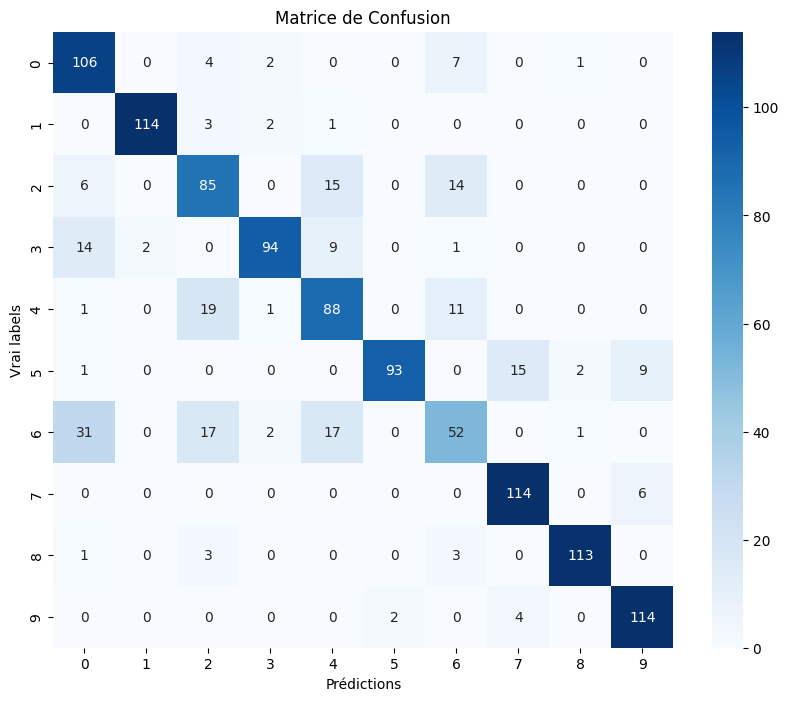

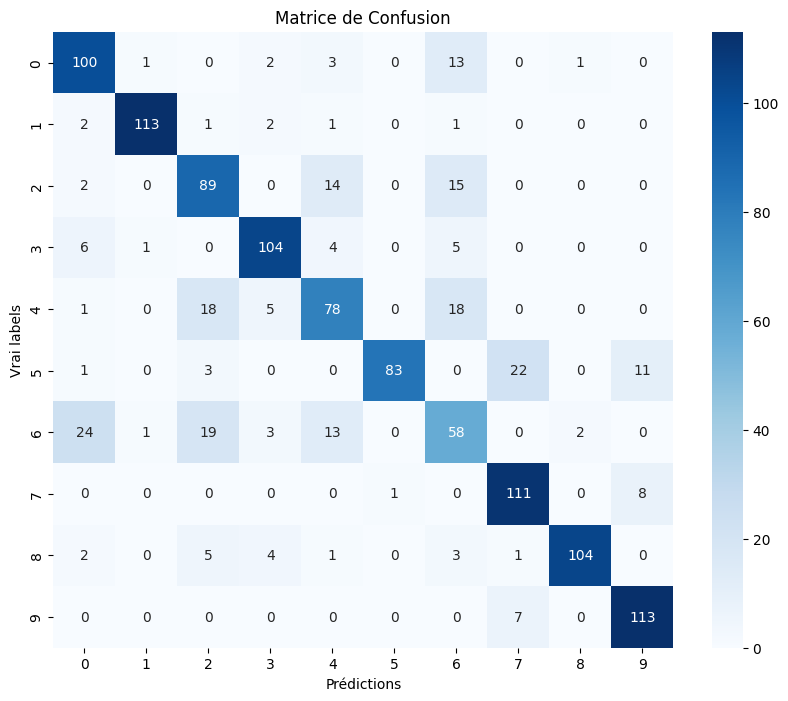

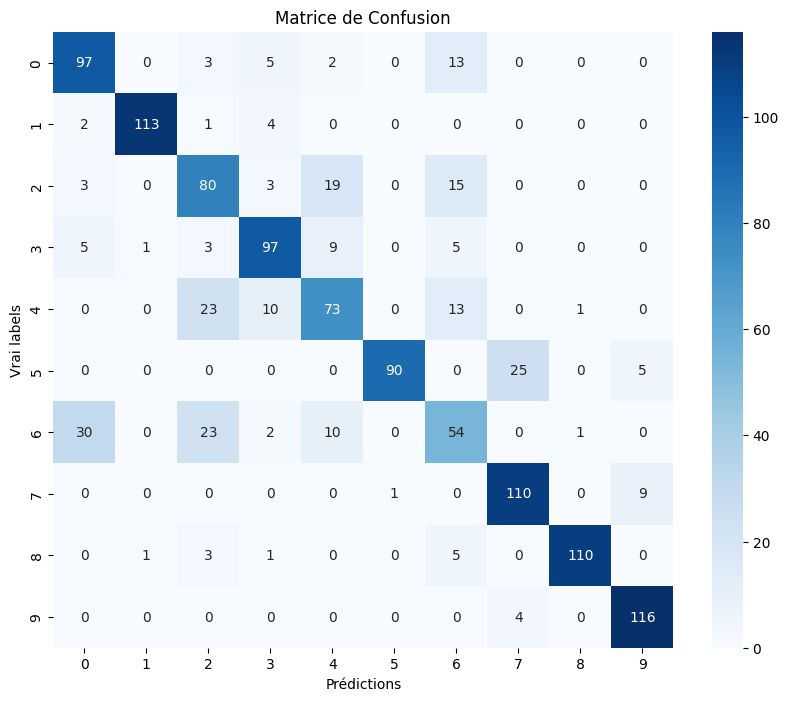

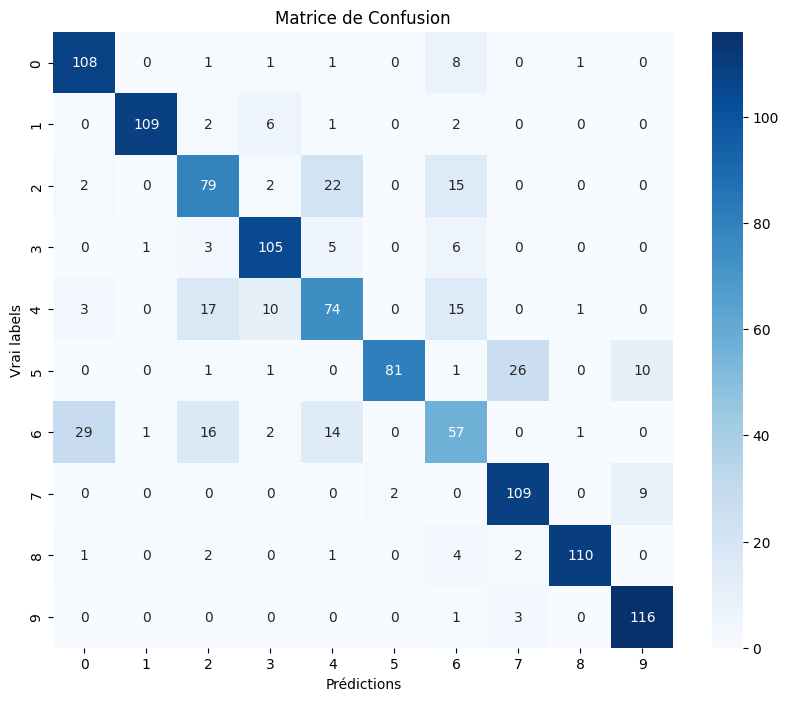

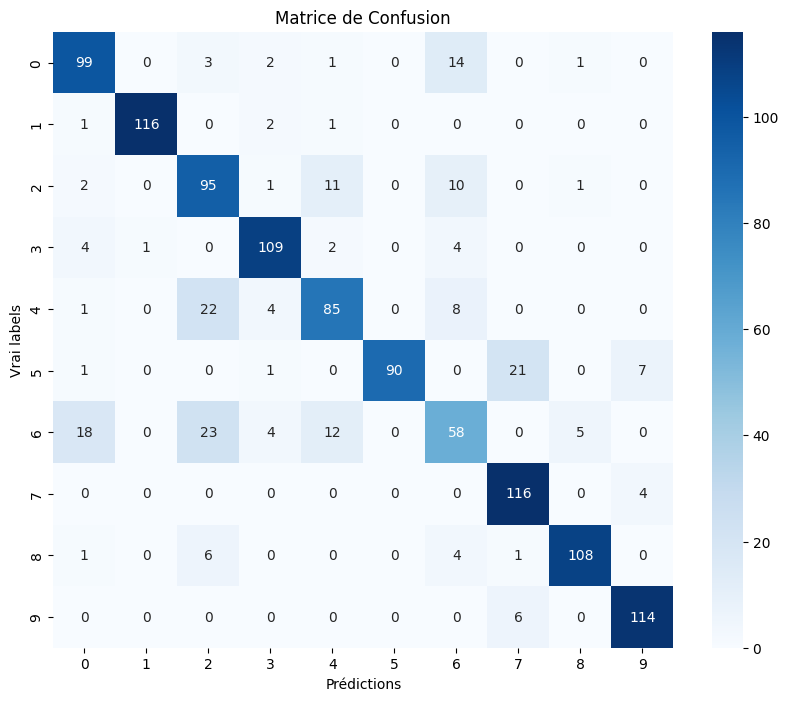

In [ ]:
X_mult = data_train.drop(columns=['label']).values
Y_mult = data_train['label'].values
X_small_mult, Y_small_mult = ev.echantillonnage_homogene(X_mult, Y_mult, 0.1)

classifier_KNN_MC = cl.ClassifierKNN_MC(X_small_mult.shape[1], 5, 10)
ev.matrice_de_confusion(classifier_KNN_MC, (X_small_mult, Y_small_mult), 5, stratified=True)